In [54]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
workspace_root = str(Path.cwd().parent)
if workspace_root not in sys.path:
    sys.path.insert(0, workspace_root)

from utils.statevector_viz import plot_statevector_real_imag, get_data_amplitudes, print_statevector, plot_statevector_real_imag, plot_statevector_modulus_phase
from utils.statevector_viz import sample_measurement_counts, print_measurement_counts


from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram

def initialize_liniar(num_qubits):
    import numpy as np
    from qiskit import QuantumCircuit
    from qiskit.circuit.library import Initialize

    dim = 2**num_qubits

    # Build the target state vector
    amplitudes = np.array([x for x in range(dim)], dtype=complex)
    norm = np.linalg.norm(amplitudes)
    amplitudes /= norm  # normalized

    # Qiskit uses little-endian: index 0 = |00...0>
    qc = QuantumCircuit(num_qubits)
    qc.initialize(amplitudes, range(num_qubits))

    return qc

def Grover_Rudolph_liniar(n):
    """
    Prepares (1/N) * sum_{x=0}^{2^n - 1} x |x>
    using the Grover-Rudolph algorithm with controlled Ry rotations.

    At each level, a controlled Ry is applied to a target qubit conditioned
    on the exact bit-prefix of all previously decided qubits, splitting
    amplitude between the left and right halves of the current index range.
    """
    import numpy as np
    from qiskit import QuantumCircuit, transpile
    from qiskit.circuit.library import RYGate

    def sum_sq(lo, hi):
        """Sum of x^2 from lo to hi via closed form."""
        if hi < lo:
            return 0.0
        def f(m): return m * (m + 1) * (2 * m + 1) / 6
        return f(hi) - (f(lo - 1) if lo > 0 else 0.0)

    dim = 2**n
    total = sum_sq(0, dim - 1)
    qc = QuantumCircuit(n)

    def build(level, lo, hi, total_sq, ctrl_bits):
        """
        level     : recursion depth (0 = MSB qubit)
        lo, hi    : current index range [lo, hi] (inclusive)
        total_sq  : sum of x^2 over [lo, hi]
        ctrl_bits : list of bits [b0, b1, ...] decided at levels 0..level-1
                    where 0 = left (lower) half, 1 = right (upper) half
        """
        if level >= n or lo >= hi or total_sq == 0:
            return

        mid = (lo + hi) // 2
        left_sq = sum_sq(lo, mid)

        # Compute rotation angle: cos^2(theta/2) = P_left / P_total
        ratio = np.clip(left_sq / total_sq, 0.0, 1.0)
        theta = 2 * np.arccos(np.sqrt(ratio))

        # Qiskit is little-endian: MSB = qubit (n-1), LSB = qubit 0
        # level 0 -> qubit (n-1), level 1 -> qubit (n-2), ...
        target = n - 1 - level

        if level == 0:
            # First qubit: unconditional Ry
            qc.ry(theta, target)
        else:
            # Subsequent qubits: Ry controlled on the exact prefix state
            # control_qubits[i] = qubit for level i (in order, MSB first)
            control_qubits = [n - 1 - i for i in range(level)]
            # ctrl_state is a binary string; rightmost char = control_qubits[0]'s required value
            ctrl_state = ''.join(str(b) for b in reversed(ctrl_bits))
            gate = RYGate(theta).control(level, ctrl_state=ctrl_state)
            qc.append(gate, control_qubits + [target])

        # Recurse: left branch (current qubit -> |0>) and right branch (-> |1>)
        build(level + 1, lo,      mid, left_sq,              ctrl_bits + [0])
        build(level + 1, mid + 1, hi,  total_sq - left_sq,   ctrl_bits + [1])

    build(0, 0, dim - 1, total, [])

    # Decompose multi-controlled Ry gates into Aer-compatible primitive gates
    return qc


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


┌──────────┐                                                      »
q_0: ───┤ U(0,0,0) ├──────────────────────────────────────────────────────»
     ┌──┴──────────┴─┐            ┌───┐┌────────────────┐┌───┐┌──────────┐»
q_1: ┤ U(1.3002,0,0) ├────────────┤ X ├┤ U(-1.3002,0,0) ├┤ X ├┤ U(π,0,π) ├»
     ├───────────────┤┌──────────┐└─┬─┘└────────────────┘└─┬─┘├──────────┤»
q_2: ┤ U(2.4981,0,0) ├┤ U(π,0,π) ├──■──────────────────────■──┤ U(π,0,π) ├»
     └───────────────┘└──────────┘                            └──────────┘»
«                             ┌───┐┌─────────────┐┌───┐┌────────────┐»
«q_0: ────────────────────────┤ X ├┤ U(-π/4,0,0) ├┤ X ├┤ U(π/4,0,0) ├»
«     ┌──────────┐┌──────────┐└─┬─┘└─────────────┘└─┬─┘└────────────┘»
«q_1: ┤ U(0,0,0) ├┤ U(0,0,0) ├──■───────────────────■────────■───────»
«     ├──────────┤└──────────┘                             ┌─┴─┐     »
«q_2: ┤ U(π,0,π) ├─────────────────────────────────────────┤ X ├─────»
«     └──────────┘                                         └───┘     »
«     ┌──────────┐            ┌───┐┌────────────┐┌───┐┌─────────────┐»
«q_0: ┤ U(0,0,0) ├────────────┤ X ├┤ U(π/4,0,0) ├┤ X ├┤ U(-π/4,0,0) ├»
«     └──────────┘            └─┬─┘└────────────┘└─┬─┘└─────────────┘»
«q_1: ──────────────────────────┼──────────────────┼─────────■───────»
«     ┌──────────┐┌──────────┐  │                  │       ┌─┴─┐     »
«q_2: ┤ U(0,0,0) ├┤ U(0,0,0) ├──■──────────────────■───────┤ X ├─────»
«     └──────────┘└──────────┘                             └───┘     »
«     ┌──────────┐                        ┌───┐┌─────────────┐┌───┐»
«q_0: ┤ U(0,0,0) ├────────────────────────┤ X ├┤ U(-π/4,0,0) ├┤ X ├»
«     ├──────────┤┌──────────┐┌──────────┐└─┬─┘└─────────────┘└─┬─┘»
«q_1: ┤ U(π,0,π) ├┤ U(0,0,0) ├┤ U(0,0,0) ├──┼───────────────────┼──»
«     ├──────────┤├──────────┤└──────────┘  │                   │  »
«q_2: ┤ U(0,0,0) ├┤ U(0,0,0) ├──────────────■───────────────────■──»
«     └──────────┘└──────────┘                                     »
«     ┌────────────┐┌──────────┐┌───┐┌────────────────┐┌───┐┌───────────────┐»
«q_0: ┤ U(π/4,0,0) ├┤ U(0,0,0) ├┤ X ├┤ U(-0.4914,0,0) ├┤ X ├┤ U(0.4914,0,0) ├»
«     └────────────┘└──────────┘└─┬─┘└────────────────┘└─┬─┘└───────────────┘»
«q_1: ────────────────────────────■──────────────────────■──────────■────────»
«      ┌──────────┐ ┌──────────┐                                  ┌─┴─┐      »
«q_2: ─┤ U(π,0,π) ├─┤ U(π,0,π) ├──────────────────────────────────┤ X ├──────»
«      └──────────┘ └──────────┘                                  └───┘      »
«     ┌──────────┐            ┌───┐┌───────────────┐┌───┐┌────────────────┐»
«q_0: ┤ U(0,0,0) ├────────────┤ X ├┤ U(0.4914,0,0) ├┤ X ├┤ U(-0.4914,0,0) ├»
«     └──────────┘            └─┬─┘└───────────────┘└─┬─┘└────────────────┘»
«q_1: ──────────────────────────┼─────────────────────┼──────────■─────────»
«     ┌──────────┐┌──────────┐  │                     │        ┌─┴─┐       »
«q_2: ┤ U(0,0,0) ├┤ U(0,0,0) ├──■─────────────────────■────────┤ X ├───────»
«     └──────────┘└──────────┘                                 └───┘       »
«        ┌──────────┐               ┌───┐┌────────────────┐┌───┐»
«q_0: ───┤ U(0,0,0) ├───────────────┤ X ├┤ U(-0.4914,0,0) ├┤ X ├»
«     ┌──┴──────────┴──┐            └─┬─┘└────────────────┘└─┬─┘»
«q_1: ┤ U(0.96376,0,0) ├──────────────┼──────────────────────┼──»
«     └──┬──────────┬──┘┌──────────┐  │                      │  »
«q_2: ───┤ U(0,0,0) ├───┤ U(0,0,0) ├──■──────────────────────■──»
«        └──────────┘   └──────────┘                            »
«     ┌───────────────┐┌──────────┐                                    »
«q_0: ┤ U(0.4914,0,0) ├┤ U(0,0,0) ├────────────────────────────────────»
«     └───────────────┘└──┬───┬───┘┌─────────────────┐┌───┐┌──────────┐»
«q_1: ────────────────────┤ X ├────┤ U(-0.96376,0,0) ├┤ X ├┤ U(π,0,π) ├»
«        ┌──────────┐     └─┬─┘    └─────────────────┘└─┬─┘└──────────┘»
«q_2: ───┤ U(π,0,π) ├───────■───────────────────────────■──────────────»
«      

Statevector amplitudes (|basis⟩ : amplitude):
  |001⟩ : 0.0845-0.0000j  (prob = 0.0071)
  |010⟩ : 0.1690-0.0000j  (prob = 0.0286)
  |011⟩ : 0.2535-0.0000j  (prob = 0.0643)
  |100⟩ : 0.3381-0.0000j  (prob = 0.1143)
  |101⟩ : 0.4226-0.0000j  (prob = 0.1786)
  |110⟩ : 0.5071-0.0000j  (prob = 0.2571)
  |111⟩ : 0.5916-0.0000j  (prob = 0.3500)
Measurement results (1024 shots):
  |000⟩ :    0  
  |001⟩ :    9  
  |010⟩ :   25  
  |011⟩ :   70  ██
  |100⟩ :  117  ████
  |101⟩ :  166  ██████
  |110⟩ :  272  ██████████
  |111⟩ :  365  ██████████████


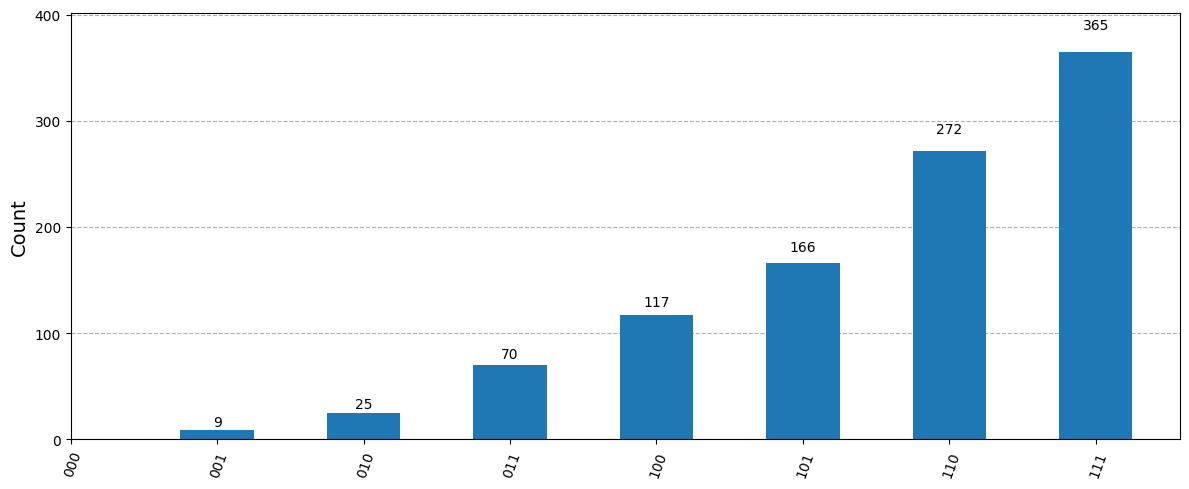

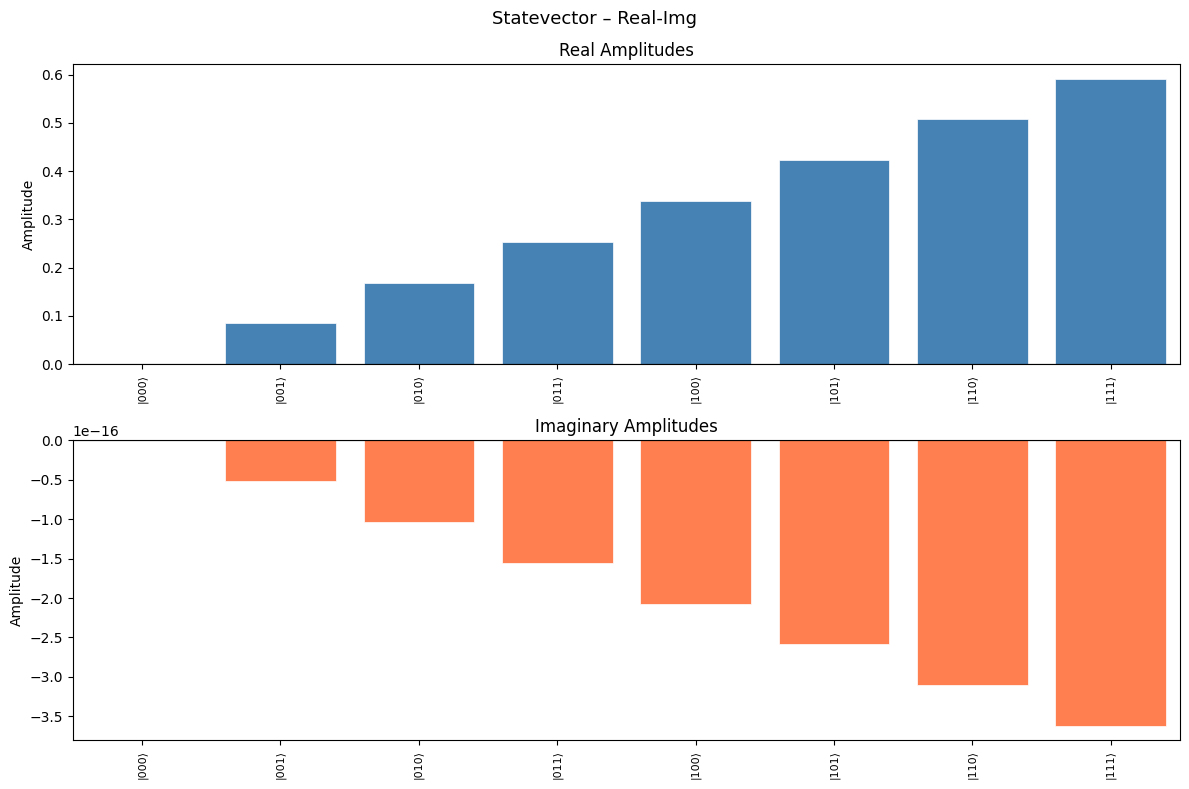

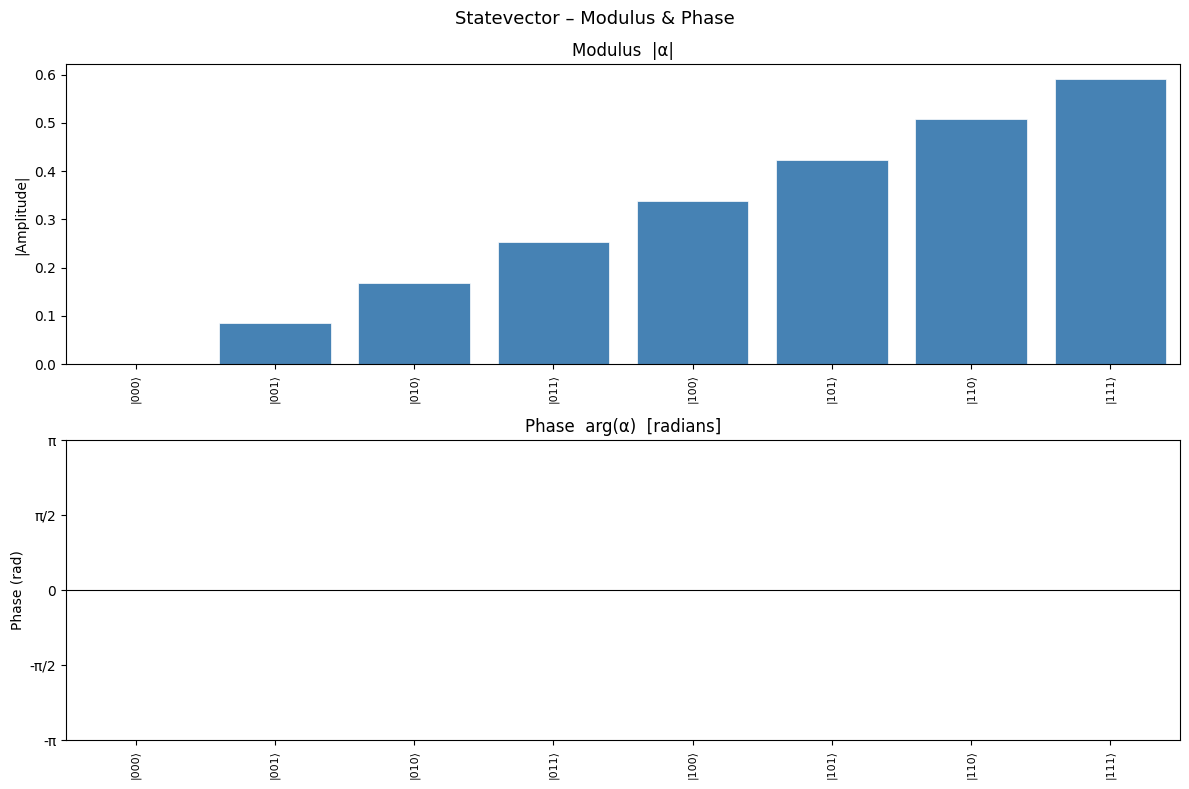

In [55]:
num_qubits = 3
qc = Grover_Rudolph_liniar(num_qubits)
# qc = initialize_liniar(num_qubits)
qc = transpile(qc, basis_gates=['u', 'cx'], optimization_level=0)
display(qc.draw())

data_amps = get_data_amplitudes(qc, num_qubits)
print_statevector(data_amps, num_qubits)
fig = plot_statevector_real_imag(data_amps, num_qubits)
fig = plot_statevector_modulus_phase(data_amps, num_qubits)

shots = 1024
counts = sample_measurement_counts(qc, num_qubits, shots=shots)
print_measurement_counts(counts, shots)
plot_histogram(counts, figsize=(12, 5), bar_labels=True,)
# fig.tight_layout()
# display(fig)

In [56]:
def Grover_Rudolph_liniar_approx(n, epsilon=0.01):
    """
    Approximate Grover-Rudolph for f(x) = x.

    Prunes rotations where the probability split is nearly deterministic:
      - ratio < epsilon       → all amplitude goes right  (skip, recurse right only)
      - ratio > 1 - epsilon   → all amplitude goes left   (skip, recurse left only)

    This exploits the smoothness of the linear distribution: at fine scales
    the split becomes nearly uniform or nearly one-sided, and skipping those
    rotations introduces only a small error while dramatically reducing gate count.

    Parameters
    ----------
    n       : number of qubits
    epsilon : pruning threshold on the probability split ratio (default 0.01)
              Tighter epsilon → more accurate, more gates.
              Looser epsilon  → fewer gates, higher approximation error.

    Returns
    -------
    qc           : transpiled QuantumCircuit
    total_nodes  : number of nodes visited in the binary tree
    applied      : number of Ry rotations actually applied (rest were pruned)
    """
    import numpy as np
    from qiskit import QuantumCircuit, transpile
    from qiskit.circuit.library import RYGate

    def sum_sq(lo, hi):
        if hi < lo:
            return 0.0
        def f(m): return m * (m + 1) * (2 * m + 1) / 6
        return f(hi) - (f(lo - 1) if lo > 0 else 0.0)

    dim = 2**n
    total = sum_sq(0, dim - 1)
    qc = QuantumCircuit(n)

    nodes_visited = [0]
    gates_applied = [0]

    def build(level, lo, hi, total_sq, ctrl_bits):
        if level >= n or lo >= hi or total_sq == 0:
            return

        nodes_visited[0] += 1
        mid = (lo + hi) // 2
        left_sq = sum_sq(lo, mid)
        ratio = np.clip(left_sq / total_sq, 0.0, 1.0)

        # --- Pruning ---
        # Nearly all amplitude goes right: treat as deterministic |1>, skip rotation
        if ratio < epsilon:
            build(level + 1, mid + 1, hi, total_sq - left_sq, ctrl_bits + [1])
            return

        # Nearly all amplitude goes left: treat as deterministic |0>, skip rotation
        if ratio > 1.0 - epsilon:
            build(level + 1, lo, mid, left_sq, ctrl_bits + [0])
            return

        # --- Apply rotation ---
        theta = 2 * np.arccos(np.sqrt(ratio))
        target = n - 1 - level
        gates_applied[0] += 1

        if level == 0:
            qc.ry(theta, target)
        else:
            control_qubits = [n - 1 - i for i in range(level)]
            ctrl_state = ''.join(str(b) for b in reversed(ctrl_bits))
            gate = RYGate(theta).control(level, ctrl_state=ctrl_state)
            qc.append(gate, control_qubits + [target])

        build(level + 1, lo,      mid, left_sq,              ctrl_bits + [0])
        build(level + 1, mid + 1, hi,  total_sq - left_sq,   ctrl_bits + [1])

    build(0, 0, dim - 1, total, [])
    qc = transpile(qc, basis_gates=['u', 'cx'], optimization_level=0)
    return qc, nodes_visited[0], gates_applied[0]


In [57]:
import numpy as np

# ── Gate count scaling: exact vs approximate ──────────────────────────────────
print(f"{'n':>4} │ {'exact Ry':>10} │ {'approx Ry (ε=0.05)':>20} │ {'pruned %':>10}")
print("─────┼────────────┼──────────────────────┼───────────")
for n in range(2, 9):
    exact_gates = 2**n - 1
    _, nodes, applied = Grover_Rudolph_liniar_approx(n, epsilon=0.05)
    pruned_pct = 100 * (1 - applied / exact_gates)
    print(f"{n:>4} │ {exact_gates:>10} │ {applied:>20} │ {pruned_pct:>9.1f}%")

# ── Accuracy check for n=5 ────────────────────────────────────────────────────
print()
n_test = 5
eps_values = [0.1, 0.05, 0.01, 0.001]
qc_exact = Grover_Rudolph_liniar(n_test)
amps_exact = get_data_amplitudes(qc_exact, n_test)

print(f"{'epsilon':>10} │ {'Ry gates':>10} │ {'L2 error':>12}")
print("───────────┼────────────┼─────────────")
for eps in eps_values:
    qc_approx, _, applied = Grover_Rudolph_liniar_approx(n_test, epsilon=eps)
    amps_approx = get_data_amplitudes(qc_approx, n_test)
    l2_err = np.linalg.norm(np.abs(amps_exact) - np.abs(amps_approx))
    print(f"{eps:>10.3f} │ {applied:>10} │ {l2_err:>12.6f}")


   n │   exact Ry │   approx Ry (ε=0.05) │   pruned %
─────┼────────────┼──────────────────────┼───────────
   2 │          3 │                    2 │      33.3%
   3 │          7 │                    6 │      14.3%
   4 │         15 │                   14 │       6.7%
   5 │         31 │                   30 │       3.2%
   6 │         63 │                   62 │       1.6%
   7 │        127 │                  126 │       0.8%
   8 │        255 │                  254 │       0.4%



AerError: 'unknown instruction: ccry_o0'